# 基礎分析：カヤノ農産

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams
import seaborn as sns
from scipy.optimize import curve_fit

sns.set_style('whitegrid')
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Hiragino Maru Gothic Pro', 'Yu Gothic', 'Meirio']

## データ前処理の前処理

In [2]:
### 変数設定 ###
# #--当初のデータ
# farm_excel = 'farm/【confidential】サンプルデータ　カヤノ農産様.xlsx'
# excel_sheet = 'カヤノ農産様　データ'
#--追加のデータ（通常のxlsxフォーマット変換後）
farm_excel = 'farm/【Confidential】サンプルデータ_カヤノ農産様_251203.xlsx'
excel_sheet = 'カヤノ農産様'
output_file = "farm/kayano_data.csv"

In [3]:
#--Excelデータファイル読み込み
df_org = pd.read_excel(farm_excel, sheet_name=excel_sheet)
print("データ量：元データ", df_org.shape)

#--データ処理(ポリゴン列の削除、年度・経過日の型)
df_org = df_org.drop(columns=['polygon']).dropna().reset_index(drop=True)
df_org['年度'] = df_org['年度'].astype(int)
df_org['経過日'] = df_org['経過日'].astype(int)
print("データ量：データ処理後", df_org.shape)

データ量：元データ (12376, 8)
データ量：データ処理後 (12376, 7)


In [4]:
#--お茶の品種リスト（準備中）
df_farm = df_org.copy()

#--お茶の品種確認（現状は圃場名出力のみ）
print("圃場名：", len(df_farm['圃場名'].unique()))
df_farm['圃場名'].unique()

圃場名： 34


array(['1_カヤノ農産', '10_カヤノ農産', '11_カヤノ農産', '12_カヤノ農産', '13_カヤノ農産',
       '14_カヤノ農産', '15_カヤノ農産', '16_カヤノ農産', '17_カヤノ農産', '18_カヤノ農産',
       '19_カヤノ農産', '2_カヤノ農産', '20_カヤノ農産', '21_カヤノ農産', '22_カヤノ農産',
       '23_カヤノ農産', '24_カヤノ農産', '25_カヤノ農産', '26_カヤノ農産', '27_カヤノ農産',
       '28_カヤノ農産', '29_カヤノ農産', '3_カヤノ農産', '30_カヤノ農産', '31_カヤノ農産',
       '32_カヤノ農産', '33_カヤノ農産', '34_カヤノ農産', '4_カヤノ農産', '5_カヤノ農産',
       '6_カヤノ農産', '7_カヤノ農産', '8_カヤノ農産', '9_カヤノ農産'], dtype=object)

In [5]:
#--処理済みデータ書き出し
df_farm.to_csv(output_file, index=False)

## データ前処理

In [2]:
#--変数設定
input_file = "farm/kayano_data.csv"
harvest_file = "farm/kayano_harvest_date.csv"

In [3]:
#--処理済みデータ読み込み
df_farm = pd.read_csv(input_file, parse_dates=['定植日','収穫日'])

#--圃場番号を取得
df_farm['圃場番号'] = df_farm['圃場名'].str.split("_",expand=True)[0].astype(int)
#--定植日＋経過日で各データの対象日を計算
df_farm['日付'] = df_farm['定植日'] + pd.to_timedelta(df_farm['経過日'], unit='D')
#--グラフ用に月と日だけの日付も作っておく（2000年はダミー）
df_farm['月日'] = df_farm['日付'].map(lambda d: pd.Timestamp(year=2000, month=d.month, day=d.day))
#--人がわかりやすいように並べ替え
df_farm = df_farm[['栽培グループ名', '圃場名', '圃場番号', '年度', '定植日', '収穫日', '経過日', '日付', '月日', 'NDVI値']]
# df_farm.head()

In [4]:
#--NDVI値がゼロは、欠損に変えておく
df_farm['NDVI値'] = df_farm['NDVI値'].mask(df_farm['NDVI値']==0, np.nan)

In [5]:
### 一番茶と二番茶で分ける
#--摘採日情報
harvest = pd.read_csv(harvest_file, parse_dates=['摘採日'])
harvest['年度'] = harvest['摘採日'].dt.year

#--一番茶と二番茶で情報を分ける
harvest1 = harvest.query("種別 == '一番茶'").reset_index(drop=True)
harvest2 = harvest.query("種別 == '二番茶'").reset_index(drop=True)

#--一番茶と二番茶でデータフレームを分ける
df_farm1 = pd.merge(df_farm, harvest1, on=['圃場名','年度'], how='inner')
df_farm2 = pd.merge(df_farm, harvest2, on=['圃場名','年度'], how='inner')

#--3月1日を起点として栽培日数を計算しておく
df_farm1['起点日'] = pd.to_datetime(df_farm1['年度'].astype(str) + '-03-01', errors='coerce')
df_farm1['栽培日数'] = (df_farm1['摘採日'] - df_farm1['起点日']).dt.days
df_farm2['起点日'] = pd.to_datetime(df_farm2['年度'].astype(str) + '-03-01', errors='coerce')
df_farm2['栽培日数'] = (df_farm2['摘採日'] - df_farm2['起点日']).dt.days

---

## データ分析

### NDVIの時系列グラフ試作

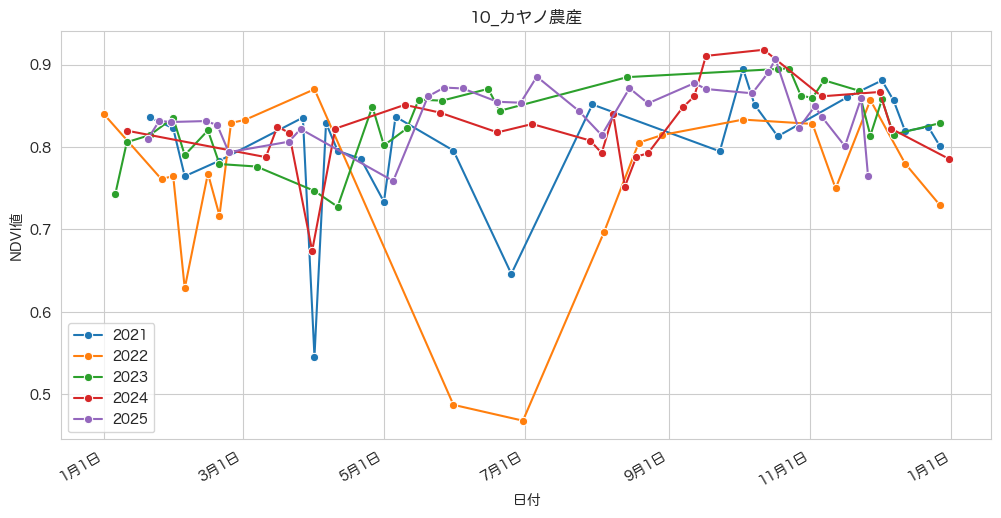

In [6]:
#--圃場ごとに、年度ごとの折れ線グラフを描画
for field, df_field in df_farm.groupby('圃場名'):
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1,1,1)
    for year, df in df_field.groupby('年度'):
        sns.lineplot(data=df, x='月日', y='NDVI値', marker='o', label=f'{year}', ax=ax)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%-m月%-d日'))
    fig.autofmt_xdate()
    plt.xlabel("日付")
    plt.legend()
    plt.title(field)
    plt.show()
    break

- NDVIの変動が大きい時がある（特に2番茶の収穫時期あたり）
- 萌芽の時期からだんだんNDVIが上がっていく、かというと必ずしもそうではない
- また１番茶の摘採の時期にNDVIがガクッと下がる、かというとそうでもない

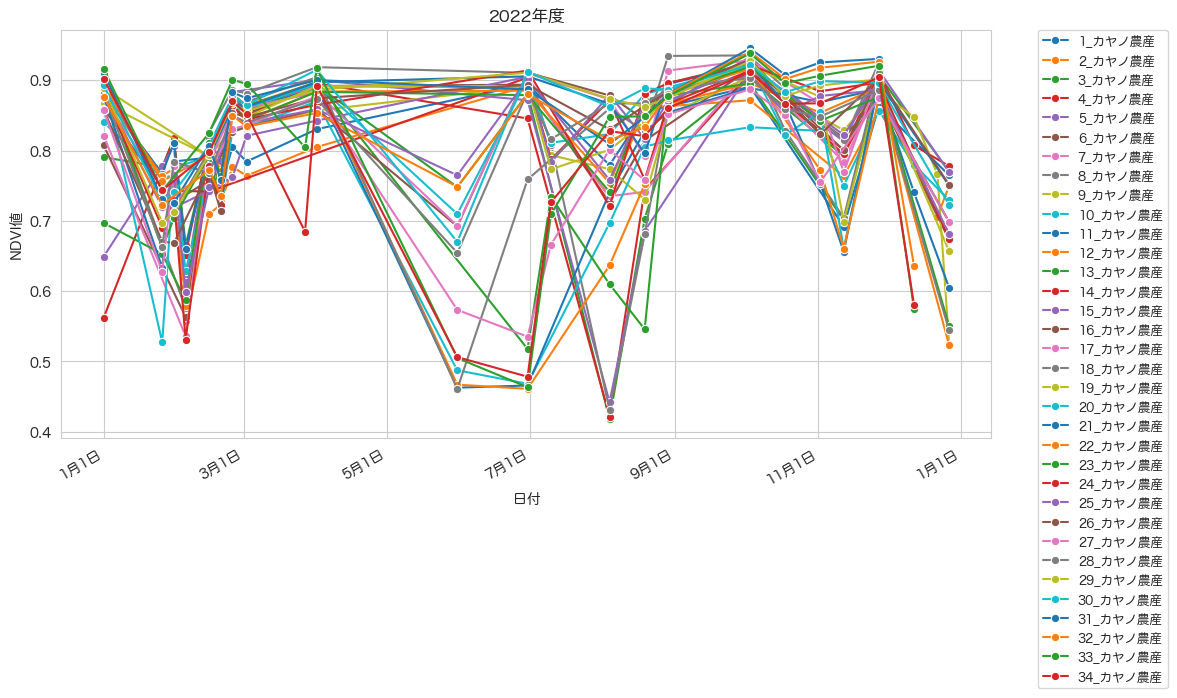

In [7]:
#--年度ごとに、圃場ごとの折れ線グラフを描画
for year, df_year in df_farm.groupby('年度', sort=True):
    if year == 2021: continue
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1,1,1)
    for (i,field), df in df_year.groupby(['圃場番号','圃場名'], sort=True):
        sns.lineplot(data=df, x='月日', y='NDVI値', marker='o', label=f'{field}', ax=ax)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%-m月%-d日'))
    fig.autofmt_xdate()
    ax.legend(
        bbox_to_anchor=(1.05, 1),  # 凡例をグラフ右外に配置
        loc='upper left',          # 凡例ボックスの基準位置
        borderaxespad=0.,          # グラフとの隙間
        fontsize=9,                # 凡例の文字サイズ（調整可）
    )
    plt.xlabel("日付")
    # plt.legend()
    plt.title(f'{year}年度')
    plt.show()
    break

- 同じ年の全圃場のNDVIを重ねると、だいたい傾向は似ている
- NDVIが大きく下がるところは、おそらく雲等による解析誤差と考えられる
- また２番茶の摘採後にNDVIがガクッと下がるかというと、そうでもなく、摘採後に上がる場合もある

### 全部描画（圃場ごと）

In [ ]:
#--画像出力先フォルダ作成
fig_dir = "fig/kayano/field"
os.makedirs(fig_dir, exist_ok=True)

#--圃場ごとに、年度ごとの折れ線グラフを描画
for field, df_field in df_farm.groupby('圃場名'):
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1,1,1)
    for year, df in df_field.groupby('年度'):
        sns.lineplot(data=df, x='月日', y='NDVI値', marker='o', label=f'{year}', ax=ax)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%-m月%-d日'))
    fig.autofmt_xdate()
    plt.xlabel("日付")
    plt.legend()
    plt.title(field)
    plt.savefig(f"{fig_dir}/{field}.png", bbox_inches='tight')
    plt.close()
    # plt.show()

### 全部描画（年度ごと）

In [43]:
#--画像出力先フォルダ作成
fig_dir = "fig/kayano/year"
os.makedirs(fig_dir, exist_ok=True)

#--年度ごとに、圃場ごとの折れ線グラフを描画
for year, df_year in df_farm.groupby('年度', sort=True):
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1,1,1)
    for (i,field), df in df_year.groupby(['圃場番号','圃場名'], sort=True):
        sns.lineplot(data=df, x='月日', y='NDVI値', marker='o', label=f'{field}', ax=ax)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%-m月%-d日'))
    fig.autofmt_xdate()
    ax.legend(
        bbox_to_anchor=(1.05, 1),  # 凡例をグラフ右外に配置
        loc='upper left',          # 凡例ボックスの基準位置
        borderaxespad=0.,          # グラフとの隙間
        fontsize=9,                # 凡例の文字サイズ（調整可）
    )
    plt.xlabel("日付")
    plt.title(f'{year}年度')
    plt.savefig(f"{fig_dir}/{year}.png", bbox_inches='tight')
    plt.close()
    # plt.show()

### 同年度の同一圃場における経過日の重複の確認
- 念のための確認　→ 重複なし

In [8]:
#--定植日に重複がある圃場・年度を書き出す
for year, df_year in df_farm.groupby('年度'):
    for field, df in df_year.groupby('圃場名'):
        if df.drop_duplicates(subset=['経過日']).shape[0] != df.shape[0]:
            print(field, year)

### 各種統計量の分析

In [9]:
#--品種ごとに栽培日数の統計量を計算
print("一番茶")
df_days1 = df_farm1.drop_duplicates(subset=['品種','圃場名','年度'], keep='last').reset_index(drop=True)
df_days1.groupby('品種').aggregate({'栽培日数':['mean','std','min','max','count']}).round(1)

一番茶


栽培日数                   
        mean  std min max count
品種                             
おくひかり   84.0  2.4  82  87     6
おくみどり   84.2  4.4  79  90    15
おくゆたか   80.0  4.7  76  86     6
さやまかおり  69.5  2.8  63  74    21
つゆひかり   74.4  7.4  63  83     9
ふうしゅん   79.8  4.0  74  85    15
めいりょく   74.5  7.4  63  81    15
やぶきた    72.0  2.6  68  77    18

In [10]:
#--品種ごとに栽培日数の統計量を計算
print("二番茶")
df_days2 = df_farm2.drop_duplicates(subset=['品種','圃場名','年度'], keep='last').reset_index(drop=True)
df_days2.groupby('品種').aggregate({'栽培日数':['mean','std','min','max','count']}).round(1)

二番茶


栽培日数                     
         mean  std  min  max count
品種                                
おくひかり   131.0  1.2  130  132     4
おくみどり   130.3  2.3  127  133    14
おくゆたか   127.7  2.3  125  130     6
さやまかおり  120.9  3.1  119  132    17
つゆひかり   124.7  3.3  122  129     9
ふうしゅん   127.6  3.7  123  132     8
めいりょく   124.7  1.2  123  126    10
やぶきた    122.2  1.4  120  125    18

- 3月1日を起点として摘採日までを栽培日数として集計した
    - 二番茶は品種ごとのばらつきが比較的小さく、品種間の違いも大きくて10日程度
    - 一番茶は品種ごとのばらつきが二番茶よりはあるがそれでも小さい方で、品種ごとの違いは大きくて２週間程度

一番茶の品種ごとヒストグラム


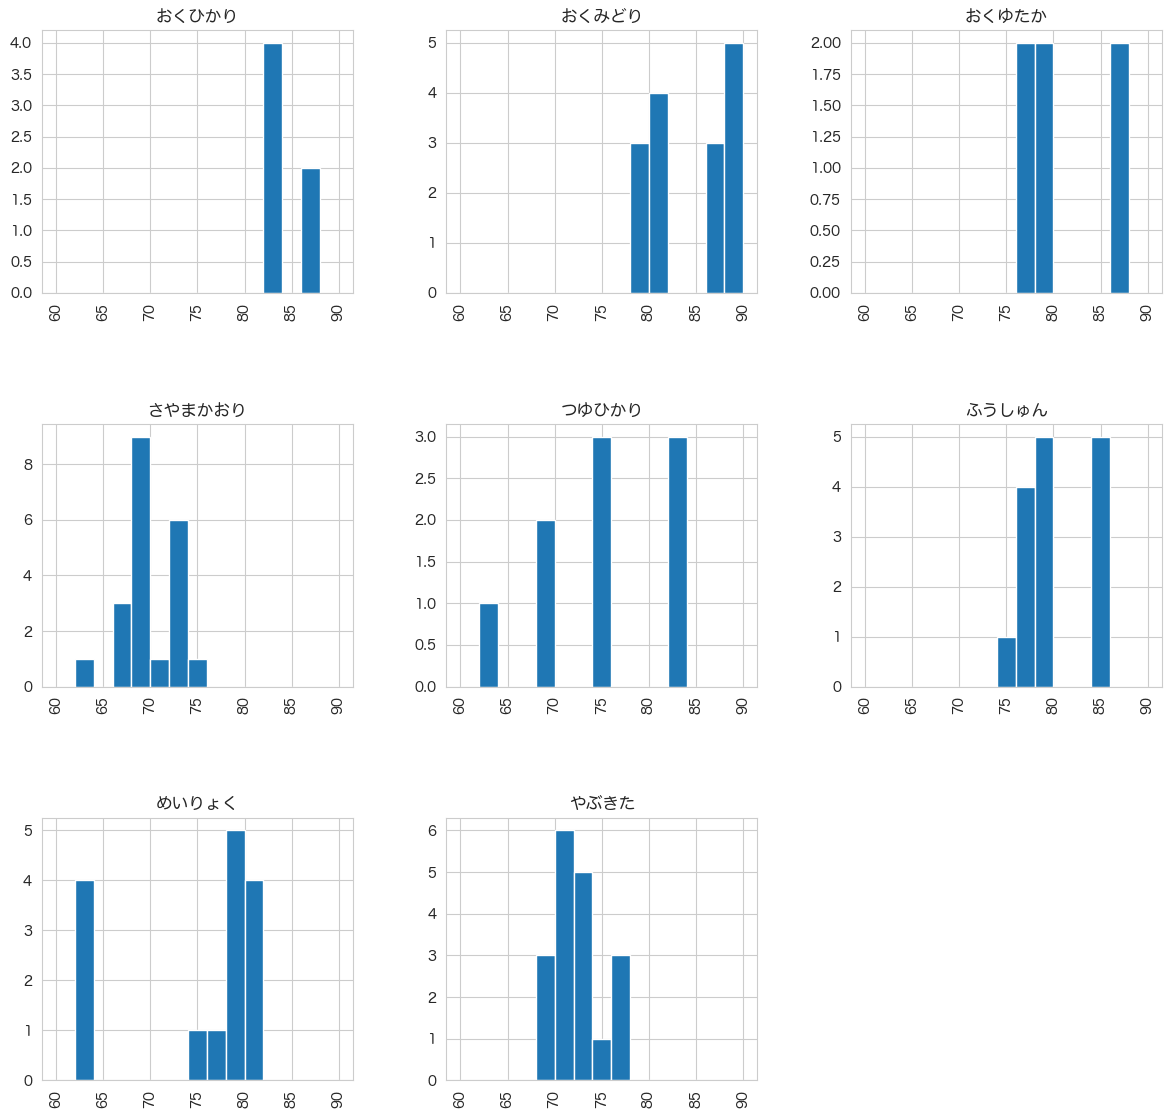

In [11]:
#--栽培グループ名ごとのヒストグラム作成
print("一番茶の品種ごとヒストグラム")
axes = df_days1.hist('栽培日数', by='品種', layout=(3,3), bins=np.arange(60,92,2), figsize=(14,14))
plt.show()

二番茶の品種ごとヒストグラム


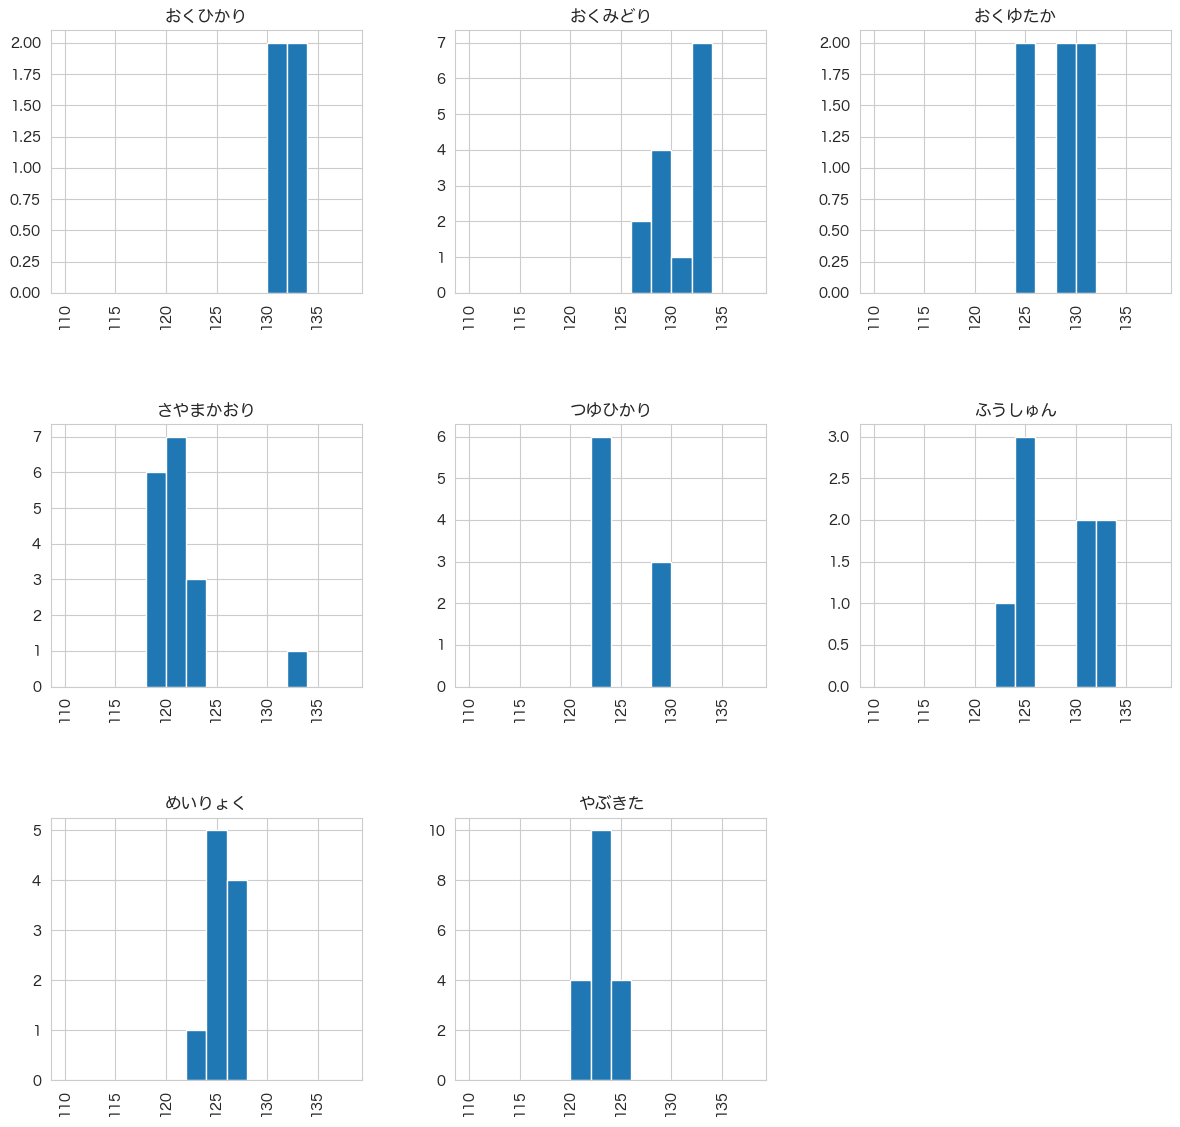

In [12]:
#--栽培グループ名ごとのヒストグラム作成
print("二番茶の品種ごとヒストグラム")
axes = df_days2.hist('栽培日数', by='品種', layout=(3,3), bins=np.arange(110,140,2), figsize=(14,14))
plt.show()

---

## 気象データを使った分析

### データ読み込み

In [13]:
#--変数設定
farm_list = "farm/kayano_farm.csv"

#--圃場IDリスト読み込み
df_IDs = pd.read_csv(farm_list)

#--圃場IDを栽培データに結合
df_farm1 = pd.merge(df_farm1, df_IDs.get(['圃場名','field_id']), on='圃場名', how='left')
df_farm2 = pd.merge(df_farm2, df_IDs.get(['圃場名','field_id']), on='圃場名', how='left')

In [14]:
#--分析で使用する気象データ読み込み
df_weather = {}
df_climate = {}
for fid in df_farm1['field_id'].unique():
    dfw = pd.read_csv(f"weather/kayano/weather_{fid}.csv", parse_dates=['date'])
    dfc = pd.read_csv(f"climate/kayano/climate_{fid}.csv", parse_dates=['date'])
    df_weather[fid] = dfw
    df_climate[fid] = dfc

### 栽培日数と気象データの分析

In [15]:
#--ユニークな圃場・栽培日数のデータセット作成
df_grow1 = df_farm1.drop_duplicates(subset=['栽培グループ名','圃場名','年度'], keep='last').reset_index(drop=True)
df_grow2 = df_farm2.drop_duplicates(subset=['栽培グループ名','圃場名','年度'], keep='last').reset_index(drop=True)

#--栽培期間における気象データの合計値を計算
def calc_wx_sum(df_grow, df_weather):
    # Tbase = 4
    wx_sum_list = []
    wx_cols = None
    for index, row in df_grow.iterrows():
        fid = row['field_id']
        s_date = row['起点日']
        e_date = row['摘採日']
        # print(fid, s_date, e_date)
        df = df_weather[fid].query("date >= @s_date and date <= @e_date").reset_index(drop=True)
        df['TMP_GDD0'] = (df['TMP_mea'] - 0).clip(lower=0).round(2)
        df['TMP_GDD10'] = (df['TMP_mea'] - 10).clip(lower=0).round(2)
        sr = df.set_index('date').sum(axis=0).round(2)
        if wx_cols is None:
            wx_cols = sr.index.tolist()
        wx_sum_list.append(sr.tolist())
    df_wx_sum = pd.DataFrame(wx_sum_list, columns=wx_cols)

    #--圃場・栽培日数データに気象データを結合
    return pd.concat([df_grow, df_wx_sum], axis=1)

df_grow1 = calc_wx_sum(df_grow1, df_weather)
df_grow2 = calc_wx_sum(df_grow2, df_weather)

#### 気温の積算値

In [16]:
#--品種ごとの積算気温のばらつきを見る
elm = "TMP_mea"
df_agg = df_grow1.groupby('品種').aggregate({elm:['mean','std','min','max','count']})
df_agg.columns = ['mean','std','min','max','count']
df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
df_agg.round(2)

,mean,std,min,max,count,CV
品種,,,,,,
おくひかり,978.53,55.38,935.5,1049.5,6,0.06
おくみどり,984.46,59.27,900.1,1063.1,14,0.06
おくゆたか,906.67,56.90,857.1,978.4,6,0.06
さやまかおり,744.11,24.80,657.4,791.4,21,0.03
つゆひかり,818.23,121.73,657.4,973.6,9,0.15
ふうしゅん,903.87,76.37,817.3,1010.6,15,0.08
めいりょく,823.77,110.32,657.4,938.8,15,0.13
やぶきた,784.02,33.54,741.2,834.7,16,0.04


In [17]:
#--品種ごとの積算気温のばらつきを見る
elm = "TMP_GDD10"
df_agg = df_grow2.groupby('品種').aggregate({elm:['mean','std','min','max','count']})
df_agg.columns = ['mean','std','min','max','count']
df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
df_agg.round(2)

,mean,std,min,max,count,CV
品種,,,,,,
おくひかり,749.95,9.76,741.5,758.4,4,0.01
おくみどり,749.44,35.72,708.1,812.1,13,0.05
おくゆたか,699.83,41.54,648.4,738.7,6,0.06
さやまかおり,607.02,50.64,568.3,786.5,17,0.08
つゆひかり,656.97,45.20,612.9,714.6,9,0.07
ふうしゅん,701.36,55.57,643.4,770.9,8,0.08
めいりょく,654.67,11.49,643.6,669.1,10,0.02
やぶきた,619.99,22.85,580.1,657.4,16,0.04


In [18]:
#--どの積算気温の取り方が最もばらつきが小さいか、変動係数で見る
def calc_CV(df_grow):
    df_CV = pd.DataFrame()
    for elm in ['TMP_mea', 'TMP_max', 'TMP_min', 'TMP_GDD0', 'TMP_GDD10']:
        df_agg = df_grow1.groupby('品種').aggregate({elm:['mean','std','min','max','count']})
        df_agg.columns = ['mean','std','min','max','count']
        df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
        df_CV[elm] = df_agg.get('CV')

    df_CV['best'] = df_CV.idxmin(axis=1)
    display(df_CV['best'].value_counts())
    display(df_CV.round(2))

calc_CV(df_grow1)
calc_CV(df_grow2)

best
TMP_max    5
TMP_mea    3
Name: count, dtype: int64

,TMP_mea,TMP_max,TMP_min,TMP_GDD0,TMP_GDD10,best
品種,,,,,,
おくひかり,0.06,0.03,0.14,0.06,0.17,TMP_max
おくみどり,0.06,0.05,0.13,0.06,0.18,TMP_max
おくゆたか,0.06,0.07,0.10,0.06,0.17,TMP_mea
さやまかおり,0.03,0.05,0.13,0.03,0.16,TMP_mea
つゆひかり,0.15,0.11,0.30,0.15,0.36,TMP_max
ふうしゅん,0.08,0.05,0.20,0.08,0.24,TMP_max
めいりょく,0.13,0.10,0.25,0.13,0.33,TMP_max
やぶきた,0.04,0.05,0.14,0.04,0.16,TMP_mea


best
TMP_max    5
TMP_mea    3
Name: count, dtype: int64

,TMP_mea,TMP_max,TMP_min,TMP_GDD0,TMP_GDD10,best
品種,,,,,,
おくひかり,0.06,0.03,0.14,0.06,0.17,TMP_max
おくみどり,0.06,0.05,0.13,0.06,0.18,TMP_max
おくゆたか,0.06,0.07,0.10,0.06,0.17,TMP_mea
さやまかおり,0.03,0.05,0.13,0.03,0.16,TMP_mea
つゆひかり,0.15,0.11,0.30,0.15,0.36,TMP_max
ふうしゅん,0.08,0.05,0.20,0.08,0.24,TMP_max
めいりょく,0.13,0.10,0.25,0.13,0.33,TMP_max
やぶきた,0.04,0.05,0.14,0.04,0.16,TMP_mea


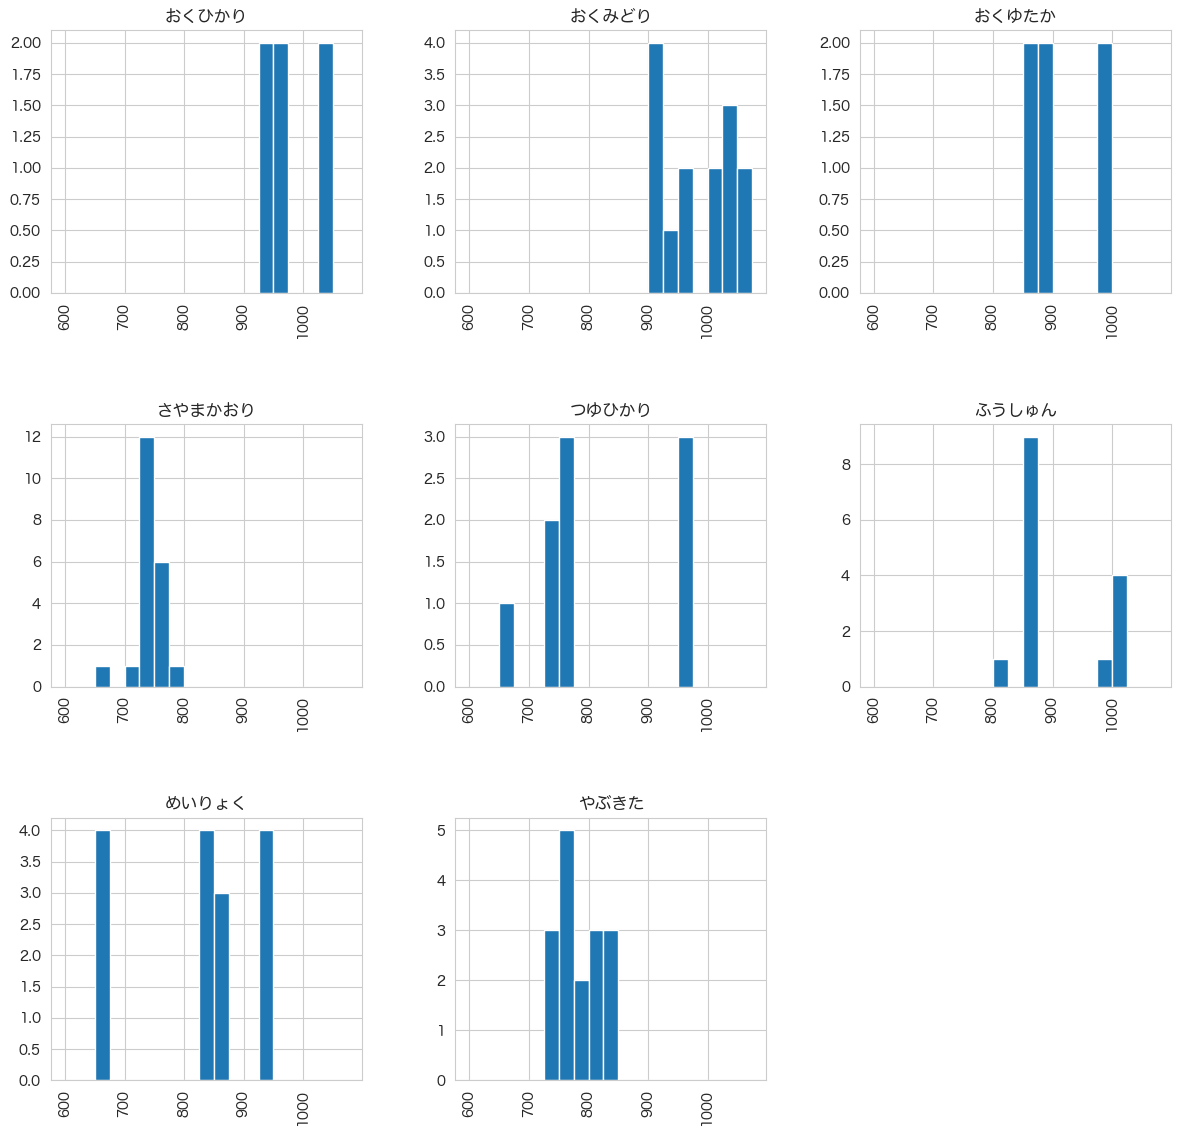

In [19]:
#--品種ごとのばらつきをヒストグラムで見る
elm = "TMP_mea"
x_max = round((df_grow1[elm].max() + 50)/50) * 50
x_min = round((df_grow1[elm].min() - 50)/50) * 50
axes = df_grow1.hist(elm, by='品種', layout=(3,3), bins=np.arange(x_min, x_max, 25), figsize=(14,14))
plt.show()

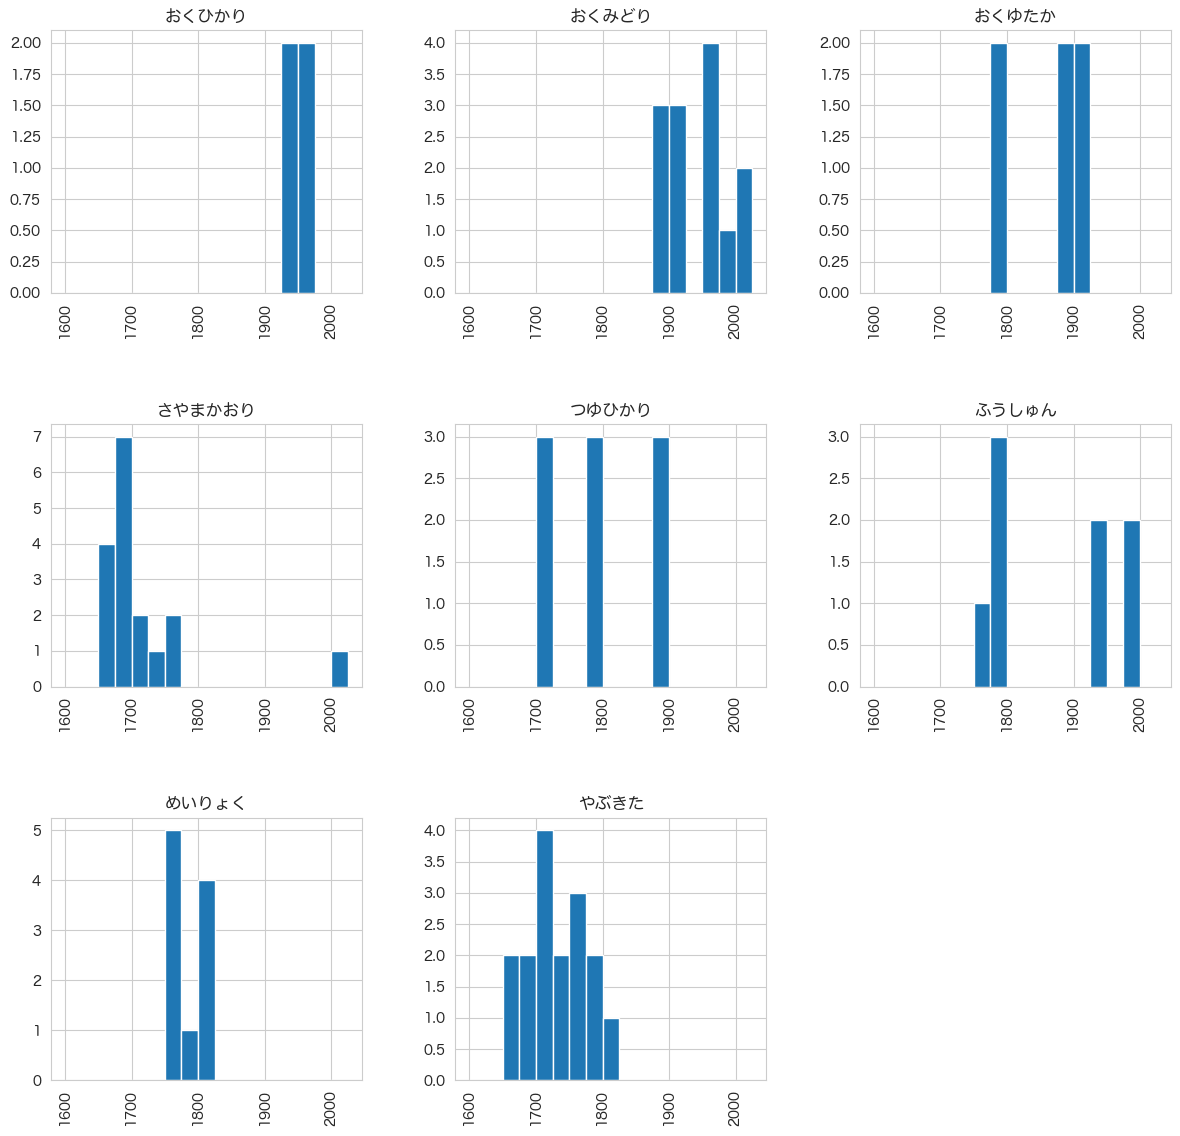

In [20]:
#--品種ごとのばらつきをヒストグラムで見る
elm = "TMP_mea"
x_max = round((df_grow2[elm].max() + 50)/50) * 50
x_min = round((df_grow2[elm].min() - 50)/50) * 50
axes = df_grow2.hist(elm, by='品種', layout=(3,3), bins=np.arange(x_min, x_max, 25), figsize=(14,14))
plt.show()

#### 日射量や日照時間の積算値

In [21]:
#--栽培グループごとの日射関係のばらつきを見る
elm = "SSD"
df_agg = df_grow1.groupby('品種').aggregate({elm:['mean','std','min','max','count']})
df_agg.columns = ['mean','std','min','max','count']
df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
df_agg.round(2)

,mean,std,min,max,count,CV
品種,,,,,,
おくひかり,490.84,30.43,460.50,527.63,6,0.06
おくみどり,484.34,30.21,429.46,508.79,14,0.06
おくゆたか,458.99,58.32,384.24,504.17,6,0.13
さやまかおり,395.14,59.98,310.97,451.93,21,0.15
つゆひかり,435.03,17.65,408.38,455.70,9,0.04
ふうしゅん,468.04,18.16,438.38,492.99,15,0.04
めいりょく,436.09,33.21,364.06,491.25,15,0.08
やぶきた,415.39,52.61,314.13,462.94,16,0.13


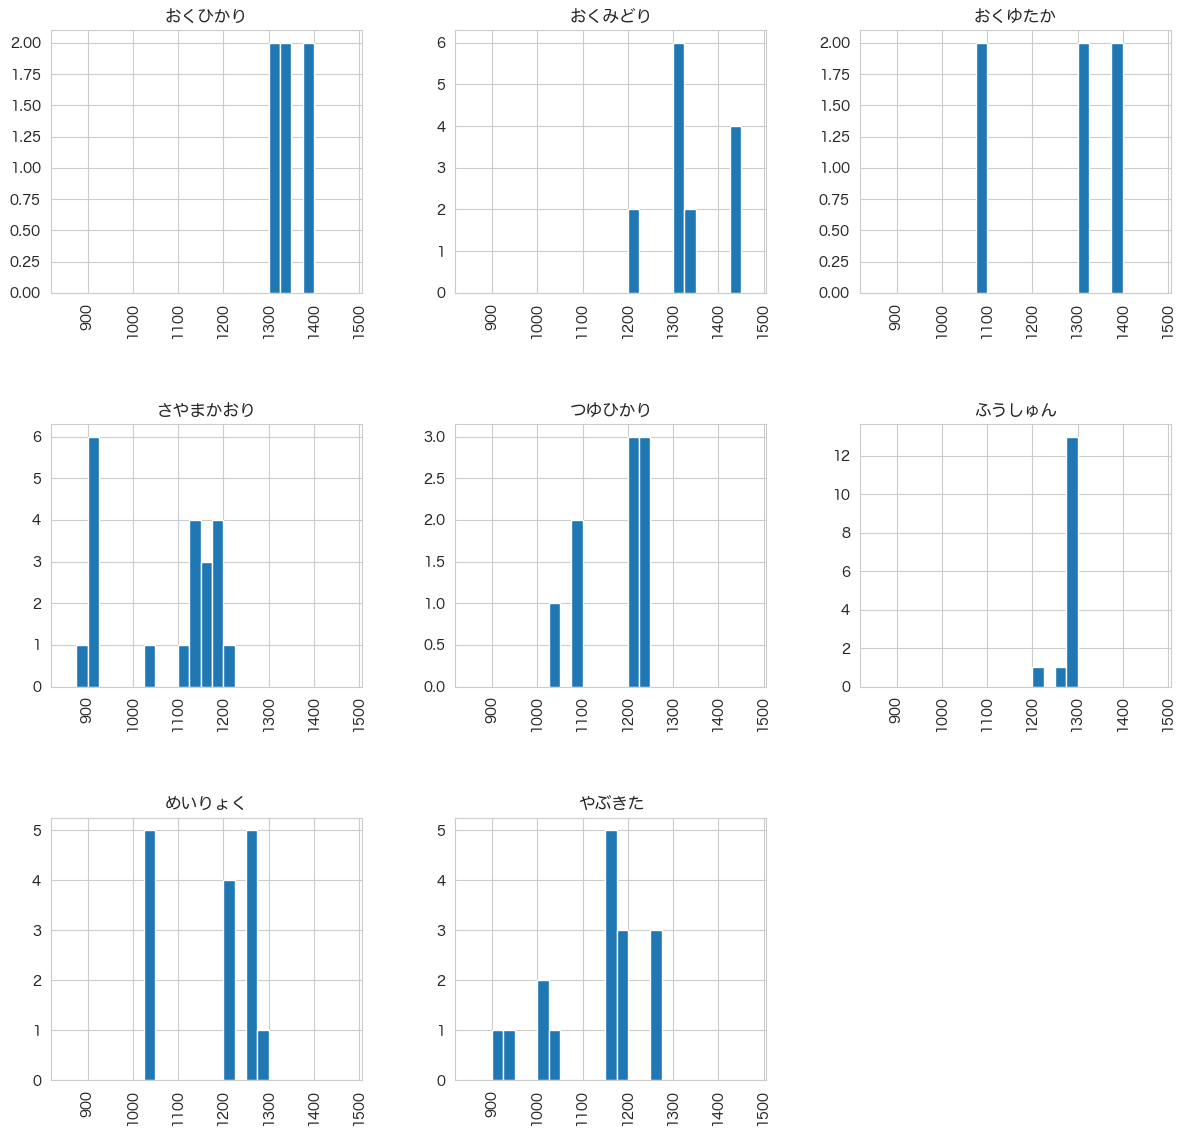

In [22]:
#--栽培グループ名ごとのばらつきをヒストグラムで見る
elm = "GSR"
x_max = round((df_grow1[elm].max() + 50)/50) * 50
x_min = round((df_grow1[elm].min() - 50)/50) * 50
axes = df_grow1.hist(elm, by='品種', layout=(3,3), bins=np.arange(x_min, x_max, 25), figsize=(14,14))
plt.show()

#### 降水量積算値や平均湿度

In [23]:
#--湿度の平均値を計算しておく
df_grow1['RH_mea'] = (df_grow1['RH'] / df_grow1['栽培日数']).round(2)
df_grow2['RH_mea'] = (df_grow2['RH'] / df_grow2['栽培日数']).round(2)

In [24]:
#--栽培グループごとの水関係の変数のばらつきを見る
elm = "APCPRA"
df_agg = df_grow1.groupby('品種').aggregate({elm:['mean','std','min','max','count']})
df_agg.columns = ['mean','std','min','max','count']
df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
df_agg.round(2)

,mean,std,min,max,count,CV
品種,,,,,,
おくひかり,441.93,46.08,403.2,500.4,6,0.10
おくみどり,440.89,16.95,419.0,461.8,14,0.04
おくゆたか,437.83,19.02,413.3,451.0,6,0.04
さやまかおり,367.22,52.63,263.9,429.0,21,0.14
つゆひかり,369.21,72.04,263.9,453.4,9,0.20
ふうしゅん,395.93,53.23,328.6,453.4,15,0.13
めいりょく,357.33,78.22,263.9,451.6,15,0.22
やぶきた,375.48,53.11,312.0,452.6,16,0.14


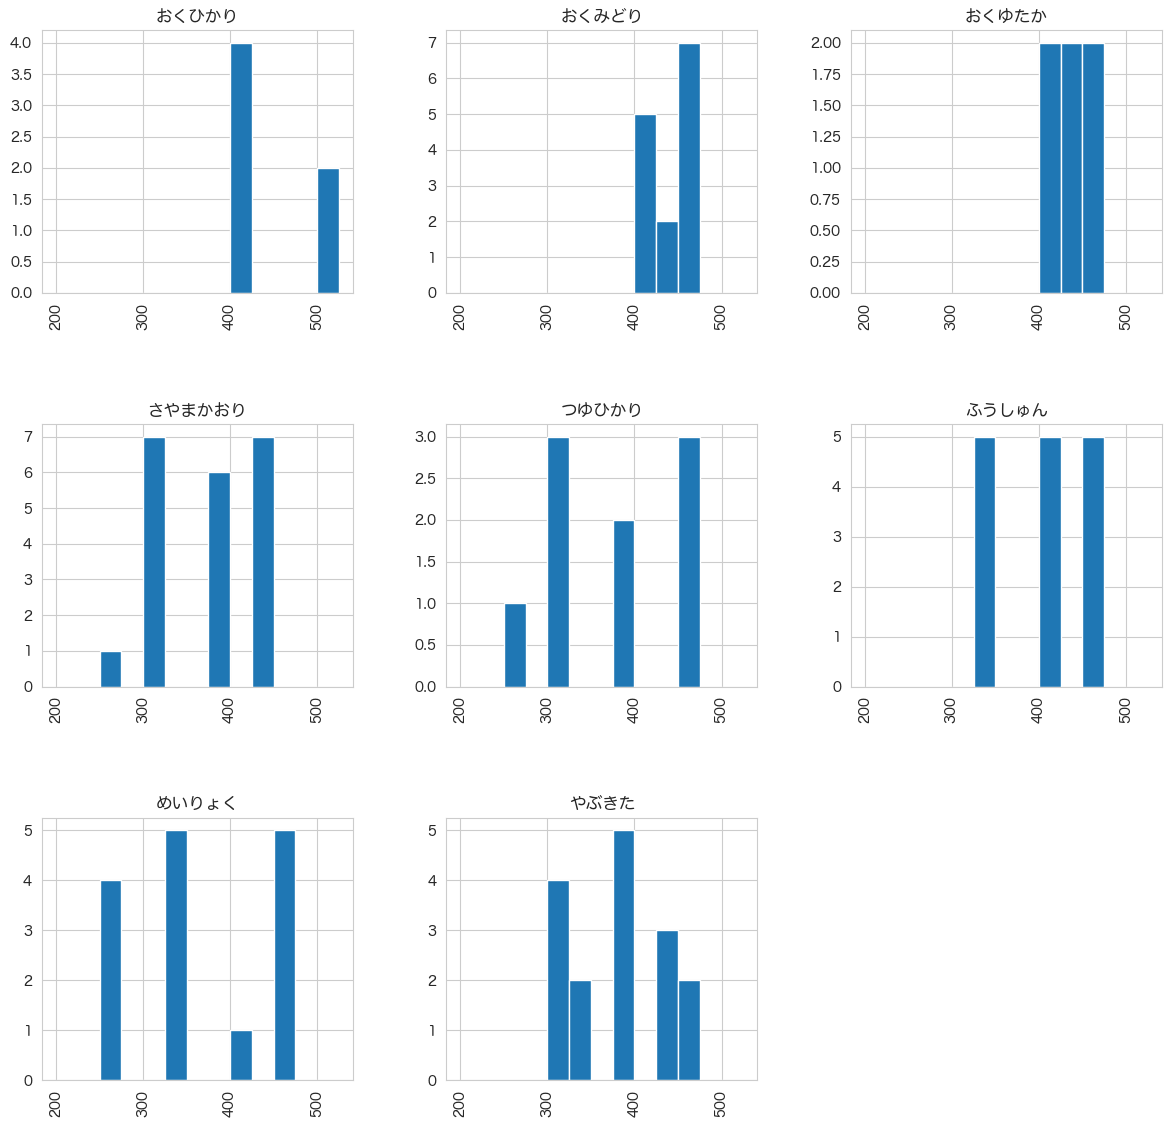

In [25]:
#--栽培グループ名ごとのばらつきをヒストグラムで見る
elm = "APCPRA"
x_max = round((df_grow1[elm].max() + 50)/50) * 50
x_min = round((df_grow1[elm].min() - 50)/50) * 50
axes = df_grow1.hist(elm, by='品種', layout=(3,3), bins=np.arange(x_min, x_max, 25), figsize=(14,14))
plt.show()

## NDVI値を曲線フィッティング

In [26]:
#--Double Logistic Model
def double_logistic(x, A, B, k1, k2, t1, t2):
    return (A / (1 + np.exp(-k1*(x - t1))) +
            B / (1 + np.exp(k2*(x - t2))))

In [27]:
#--画像出力先フォルダ作成
fig_dir = "fig/kayano/sigmoid"
os.makedirs(fig_dir, exist_ok=True)

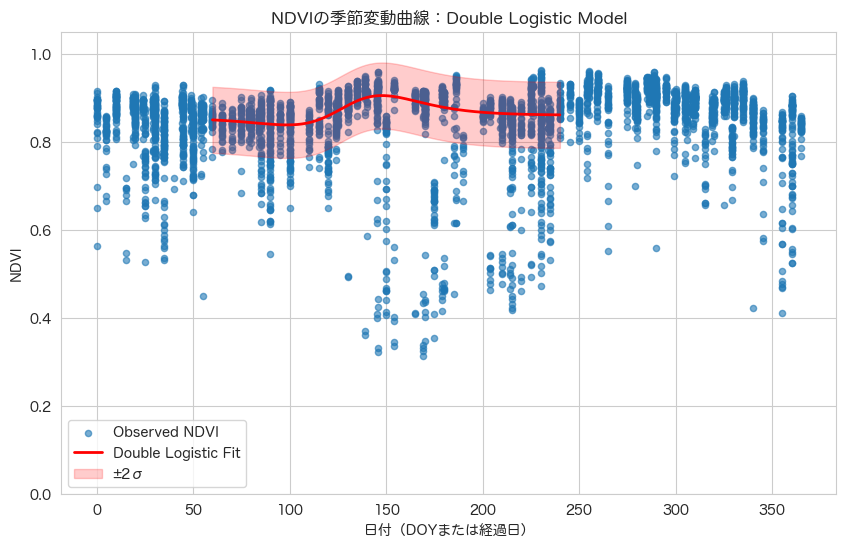

In [28]:
#--Double Logisticでフィッティングする期間を選択
df_curve = df_farm.query("59 <= 経過日 <= 242").reset_index(drop=True)
#--NDVIがある値未満を異常値として欠損に変える
df_curve['NDVI値'] = df_curve['NDVI値'].mask(df_curve['NDVI値'] < 0.75, np.nan)

#--Double Logisticでフィッティング
x = df_curve.dropna()['経過日'].values
y = df_curve.dropna()['NDVI値'].values
p0 = [0.5, 0.5, 0.1, 0.1, 100, 200] # 初期値
params, cov = curve_fit(double_logistic, x, y, p0=p0, maxfev=20000)

#--曲線描画用の変数
x_fit = np.linspace(min(x), max(x), 300)
y_fit = double_logistic(x_fit, *params)

#--残差と標準偏差を計算し、±2σの帯を計算
y_pred = double_logistic(x, *params)
residuals = y - y_pred
sigma = np.std(residuals)
upper = y_fit + 2*sigma
lower = y_fit - 2*sigma

plt.figure(figsize=(10,6))
plt.scatter(df_farm.dropna()['経過日'].values, df_farm.dropna()['NDVI値'].values, s=20, alpha=0.6, label='Observed NDVI')
plt.plot(x_fit, y_fit, 'r-', linewidth=2, label='Double Logistic Fit')
plt.fill_between(x_fit, lower, upper, color='r', alpha=0.2, label='±2σ')
plt.xlabel("日付（DOYまたは経過日）")
plt.ylabel("NDVI")
plt.ylim(0,1.05)
plt.legend()
plt.title("NDVIの季節変動曲線：Double Logistic Model")
plt.show()

In [29]:
#--年度ごとに、圃場ごとの折れ線グラフを描画
for year, df_year in df_farm.groupby('年度', sort=True):
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1,1,1)
    for (i,field), df in df_year.groupby(['圃場番号','圃場名'], sort=True):
        sns.lineplot(data=df, x='経過日', y='NDVI値', marker='o', ax=ax)
    sns.lineplot(x=x_fit, y=y_fit, c='black', linestyle='--', ax=ax)
    ax.fill_between(x_fit, lower, upper, alpha=0.3)
    plt.title(f'{year}年度')
    plt.xlim(0,365)
    plt.savefig(f"{fig_dir}/{year}.png", bbox_inches='tight')
    plt.close()
    # plt.show()

# END